# Criação dos dados

In [1]:
import numpy as np
import csv

n=1000000             # Quantidade de pontos
k=16                  # Quantidade de centróides
np.random.seed(2112)

def gerar_dados(N):
    faixas = [
        np.random.uniform(0, 2,   N//4),
        np.random.uniform(10,12,  N//4),
        np.random.uniform(20,22,  N//4),
        np.random.uniform(30,32,  N - 3*(N//4))
    ]
    return np.concatenate(faixas)


# Gera os pontos e os centróides iniciais
dados = gerar_dados(n)
centroides = np.random.uniform(0, 1000, k)

# Salva os dados em data.csv
with open("dados.csv", "w", newline="") as f:
    writer = csv.writer(f)
    for x in dados:
        writer.writerow([x])

# Salva os centróides em centroides_iniciais.csv
with open("centroides_iniciais.csv", "w", newline="") as f:
    writer = csv.writer(f)
    for c in centroides:
        writer.writerow([c])

print(f" {n} pontos e {k} centróides")

 1000000 pontos e 16 centróides


# Etapa 0: Sequencial (baseline) - kmeans_1d_naive.c

In [2]:
%%writefile kmeans_1d_naive.c

/* kmeans_1d_naive.c
    K-means 1D (C99), implementação "naive":
   - Lê X (N linhas) e C_init (K linhas) de CSVs sem cabeçalho
   - Itera assignment + update até max_iter ou variação relativa do SSE < eps
   - Salva assign (N linhas) e centróides finais (K linhas)

   Compilar: gcc -O2 -std=c99 kmeans_1d_naive.c -o kmeans_1d_naive -lm
   Uso:      ./kmeans_1d_naive dados.csv centroides_iniciais.csv [max_iter=50] [eps=1e-4] assign.csv centroids.csv
*/

#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <math.h>
#include <time.h>
#include <sys/time.h>

/* ---------- utilitários CSV ---------- */
static int count_rows(const char *path){
    FILE *f = fopen(path, "r");
    if(!f){ fprintf(stderr,"Erro ao abrir %s\n", path); exit(1); }
    int rows=0; char line[8192];
    while(fgets(line,sizeof(line),f)){
        int only_ws=1;
        for(char *p=line; *p; p++){
            if(*p!=' ' && *p!='\t' && *p!='\n' && *p!='\r'){ only_ws=0; break; }
        }
        if(!only_ws) rows++;
    }
    fclose(f);
    return rows;
}

static double *read_csv_1col(const char *path, int *n_out){
    int R = count_rows(path);
if(R<=0){ fprintf(stderr,"Arquivo vazio: %s\n", path); exit(1); }
    double *A = (double*)malloc((size_t)R * sizeof(double));
if(!A){ fprintf(stderr,"Sem memoria para %d linhas\n", R); exit(1); }
    FILE *f = fopen(path, "r");
if(!f){ fprintf(stderr,"Erro ao abrir %s\n", path); free(A); exit(1); }
    char line[8192];
    int r=0;
    while(fgets(line,sizeof(line),f)){
        int only_ws=1;
        for(char *p=line; *p; p++){
            if(*p!=' ' && *p!='\t' && *p!='\n' && *p!='\r'){ only_ws=0; break; }
        }
        if(only_ws) continue;
        const char *delim = ",; \t";
        char *tok = strtok(line, delim);
        if(!tok) continue;
        A[r++] = atof(tok);
    }
    fclose(f);
    *n_out = R;
    return A;
}

static void write_assign_csv(const char *path, const int *assign, int N){
    if(!path) return;
    FILE *f = fopen(path, "w");
    if(!f){ fprintf(stderr,"Erro ao abrir %s para escrita\n", path); return; }
    for(int i=0;i<N;i++) fprintf(f, "%d\n", assign[i]);
    fclose(f);
}

static void write_centroids_csv(const char *path, const double *C, int K){
    if(!path) return;
    FILE *f = fopen(path, "w");
    for(int c=0;c<K;c++) fprintf(f, "%.6f\n", C[c]);
    fclose(f);
}

/* ---------- Etapas do K-means ---------- */

/* Assignment: associa cada ponto X[i] ao centróide mais próximo */
static double assignment_step_1d(const double *X, const double *C, int *assign, int N, int K){
    double sse = 0.0;
    for(int i=0;i<N;i++){
        int best = -1;
        double bestd = 1e300;
        for(int c=0;c<K;c++){
            double diff = X[i] - C[c];
            double d = diff * diff;
            if(d < bestd){ bestd = d; best = c; }
        }
        assign[i] = best;
        sse += bestd;
    }
    return sse;
}
/* update: média dos pontos de cada cluster (1D)
se cluster vazio, copia X[0] (estratégia naive) */
static void update_step_1d(const double *X, double *C, const int *assign, int N, int K) {
    double *sum = (double*)calloc((size_t)K, sizeof(double));
    int *cnt = (int*)calloc((size_t)K, sizeof(int));
    if(!sum || !cnt){ fprintf(stderr,"Sem memoria no update\n"); exit(1); }
    for(int i=0;i<N;i++){
        int a = assign[i];
        cnt[a] += 1;
        sum[a] += X[i];
    }
    for(int c=0;c<K;c++){
        if(cnt[c] > 0) C[c] = sum[c] / (double)cnt[c];
        else C[c] = X[0]; /* simples: cluster vazio recebe o primeiro */
    }
    free(sum); free(cnt);
}

/* ---------- Loop principal ---------- */
static void kmeans_1d(const double *X, double *C, int *assign,
                      int N, int K, int max_iter, double eps,
                      int *iters_out, double *sse_out)
{
    double prev_sse = 1e300;
    double sse = 0.0;
    int it;
    for(it=0; it<max_iter; it++){
        sse = assignment_step_1d(X, C, assign, N, K);
        /* parada por variação relativa do SSE */
        double rel = fabs(sse - prev_sse) / (prev_sse > 0.0 ? prev_sse : 1.0);
        if(rel < eps){ it++; break; }
        update_step_1d(X, C, assign, N, K);
        prev_sse = sse;
    }
    *iters_out = it;
    *sse_out = sse;
    printf("Iter %d SSE %.6f\n", it, sse);
}

/* ---------- main ---------- */
int main(int argc, char **argv){
    if(argc < 3){
        printf("Uso: %s dados.csv centroides_iniciais.csv [max_iter=50] [eps=1e-4] assign.csv centroids.csv\n", argv[0]);
        printf("Obs: arquivos CSV com 1 coluna (1 valor por linha), sem cabeçallho");
        return 1;
    }

    const char *pathX = argv[1];
    const char *pathC = argv[2];
    int max_iter = (argc>3)? atoi(argv[3]) : 50;
    double eps   = (argc>4)? atof(argv[4]) : 1e-4;
    const char *outAssign   = (argc>5)? argv[5] : NULL;
    const char *outCentroid = (argc>6)? argv[6] : NULL;
    if(max_iter <= 0 || eps <= 0.0){
        fprintf(stderr,"Parâmetros inválidos: max_iter>0 e eps>0\n");
        return 1;
    }
    int N=0, K=0;
    double *X = read_csv_1col(pathX, &N);
    double *C = read_csv_1col(pathC, &K);
    int *assign = (int*)malloc((size_t)N * sizeof(int));

    struct timeval start, end;
    gettimeofday(&start, NULL);

    int iters = 0; double sse = 0.0;
    kmeans_1d(X, C, assign, N, K, max_iter, eps, &iters, &sse);

    gettimeofday(&end, NULL);
    double ms = (end.tv_sec - start.tv_sec) * 1000.0 +
                (end.tv_usec - start.tv_usec) / 1000.0;

    printf("K-means 1D (naive)\n");
    printf("N=%d K=%d max_iter=%d eps=%g\n", N, K, max_iter, eps);
    printf("Iterações: %d | SSE final: %.6f | Tempo: %.1f ms\n", iters, sse, ms);

    write_assign_csv(outAssign, assign, N);
    write_centroids_csv(outCentroid, C, K);

    free(assign); free(X); free(C);
    return 0;
}

Overwriting kmeans_1d_naive.c


In [3]:
%%shell

gcc -O2 -std=c99 kmeans_1d_naive.c -o kmeans_1d_naive -lm
# ./kmeans_1d_naive dados.csv centroides_iniciais.csv 50 0.000001 assign.csv centroids.csv
# cat centroids.csv


# Etapa 1: OpenMP (CPU) - kmeans_1d_omp.c

In [4]:
%%writefile kmeans_1d_omp.c

#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <math.h>
#include <sys/time.h>
#include <omp.h>

/* ---------- utilitários CSV ---------- */
static int count_rows(const char *path){
    FILE *f = fopen(path, "r");
    if(!f){ fprintf(stderr,"Erro ao abrir %s\n", path); exit(1); }
    int rows=0; char line[8192];
    while(fgets(line,sizeof(line),f)){
        int only_ws=1;
        for(char *p=line; *p; p++){
            if(*p!=' ' && *p!='\t' && *p!='\n' && *p!='\r'){ only_ws=0; break; }
        }
        if(!only_ws) rows++;
    }
        fclose(f);
    return rows;
}

static double *read_csv_1col(const char *path, int *n_out){
    int R = count_rows(path);
if(R<=0){ fprintf(stderr,"Arquivo vazio: %s\n", path); exit(1); }
    double *A = (double*)malloc((size_t)R * sizeof(double));
if(!A){ fprintf(stderr,"Sem memoria para %d linhas\n", R); exit(1); }
    FILE *f = fopen(path, "r");
if(!f){ fprintf(stderr,"Erro ao abrir %s\n", path); free(A); exit(1); }
    char line[8192];
    int r=0;
    while(fgets(line,sizeof(line),f)){
        int only_ws=1;
        for(char *p=line; *p; p++){
            if(*p!=' ' && *p!='\t' && *p!='\n' && *p!='\r'){ only_ws=0; break; }
        }
        if(only_ws) continue;
        const char *delim = ",; \t";
        char *tok = strtok(line, delim);
        if(!tok) continue;
        A[r++] = atof(tok);
    }

    fclose(f);
    *n_out = R;
    return A;
}

static void write_assign_csv(const char *path, const int *assign, int N){
    if(!path) return;
    FILE *f = fopen(path, "w");
    if(!f){ fprintf(stderr,"Erro ao abrir %s para escrita\n", path); return; }
    for(int i=0;i<N;i++) fprintf(f, "%d\n", assign[i]);
    fclose(f);
}

static void write_centroids_csv(const char *path, const double *C, int K){
    if(!path) return;
    FILE *f = fopen(path, "w");
    for(int c=0;c<K;c++) fprintf(f, "%.6f\n", C[c]);
    fclose(f);
}

static double assignment_step_1d(const double *X, const double *C, int *assign, int N, int K){
    double sse = 0.0;

    #pragma omp parallel for reduction(+:sse) schedule(static)
    for(int i=0;i<N;i++){
        int best = -1;
        double bestd = 1e300;
        for(int c=0;c<K;c++){
            double diff = X[i] - C[c];
            double d = diff * diff;
            if(d < bestd){ bestd = d; best = c; }
        }
        assign[i] = best;
        sse += bestd;
    }

    return sse;
}

static void update_step_1d(const double *X, double *C, const int *assign, int N, int K){
    int nthreads = omp_get_max_threads();

    double **sum_thread = (double**)malloc(nthreads * sizeof(double*));
    int **cnt_thread = (int**)malloc(nthreads * sizeof(int*));

    for(int t=0;t<nthreads;t++){
        sum_thread[t] = (double*)calloc(K, sizeof(double));
        cnt_thread[t] = (int*)calloc(K, sizeof(int));
    }

    #pragma omp parallel
    {
        int tid = omp_get_thread_num();
        #pragma omp for schedule(static)
        for(int i=0;i<N;i++){
            int a = assign[i];
            cnt_thread[tid][a] += 1;
            sum_thread[tid][a] += X[i];
        }
    }

    double *sum = (double*)calloc(K, sizeof(double));
    int *cnt = (int*)calloc(K, sizeof(int));

    for(int t=0;t<nthreads;t++){
        for(int c=0;c<K;c++){
            sum[c] += sum_thread[t][c];
            cnt[c] += cnt_thread[t][c];
        }
        free(sum_thread[t]);
        free(cnt_thread[t]);
    }
    free(sum_thread);
    free(cnt_thread);

    for(int c=0;c<K;c++){
        if(cnt[c] > 0) C[c] = sum[c] / (double)cnt[c];
        else           C[c] = X[0]; // cluster vazio => estratégia simples
    }

    free(sum);
    free(cnt);
}

static void kmeans_1d(const double *X, double *C, int *assign, int N, int K, int max_iter, double eps, int *iters_out, double *sse_out){
    double prev_sse = 1e300;
    double sse = 0.0;
    int it;
    for(it=0; it<max_iter; it++){
        sse = assignment_step_1d(X, C, assign, N, K);
        double rel = fabs(sse - prev_sse) / (prev_sse > 0.0 ? prev_sse : 1.0);
        if(rel < eps){ it++; break; }
        update_step_1d(X, C, assign, N, K);
        prev_sse = sse;
    }
    *iters_out = it;
    *sse_out = sse;
    printf("Iter %d SSE %.6f\n", it, sse);

}

int main(int argc, char **argv){
    if(argc < 3){
        printf("Uso: %s dados.csv centroides_iniciais.csv [max_iter=50] [eps=1e-4] assign.csv centroids.csv\n", argv[0]);
        return 1;
    }

    const char *pathX = argv[1];
    const char *pathC = argv[2];
    int max_iter = (argc>3)? atoi(argv[3]) : 50;
    double eps   = (argc>4)? atof(argv[4]) : 1e-4;
    const char *outAssign   = (argc>5)? argv[5] : "assign.csv";
    const char *outCentroid = (argc>6)? argv[6] : "centroids.csv";

    int N=0, K=0;
    double *X = read_csv_1col(pathX, &N);
    double *C = read_csv_1col(pathC, &K);
    int *assign = (int*)malloc((size_t)N * sizeof(int));

    struct timeval start, end;
    gettimeofday(&start, NULL);

    int iters = 0; double sse = 0.0;
    kmeans_1d(X, C, assign, N, K, max_iter, eps, &iters, &sse);

    gettimeofday(&end, NULL);
    double ms = (end.tv_sec - start.tv_sec) * 1000.0 +
                (end.tv_usec - start.tv_usec) / 1000.0;

    printf("K-means 1D (OpenMP)\n");
    printf("N=%d K=%d max_iter=%d eps=%g\n", N, K, max_iter, eps);
    printf("Iterações: %d | SSE final: %.6f | Tempo: %.1f ms | Threads: %d\n",
           iters, sse, ms, omp_get_max_threads());

    write_assign_csv(outAssign, assign, N);
    write_centroids_csv(outCentroid, C, K);

    free(assign); free(X); free(C);
    return 0;
}

Overwriting kmeans_1d_omp.c


In [5]:
%%shell

gcc -O2 -fopenmp -std=c99 kmeans_1d_omp.c -o kmeans_1d_omp -lm
# ./kmeans_1d_omp dados.csv centroides_iniciais.csv 1000 0.0001 assign.csv centroids.csv


# Etapa 2: CUDA (GPU) - kmeans_1d_cuda.cu

In [6]:
%%writefile kmeans_1d_cuda.cu

#define TIC(t) gettimeofday(&t, NULL)
#define TOC_MS(t0,t1) (((t1.tv_sec - t0.tv_sec)*1000.0) + ((t1.tv_usec - t0.tv_usec)/1000.0))

#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <math.h>
#include <sys/time.h>
#include <cuda.h>

/* ---------- utilitários CSV (float) ---------- */
static int count_rows(const char *path){
    FILE *f = fopen(path, "r");
    if(!f){ fprintf(stderr,"Erro ao abrir %s\n", path); exit(1); }
    int rows=0; char line[8192];
    while(fgets(line,sizeof(line),f)){
        int only_ws=1;
        for(char *p=line; *p; p++){
            if(*p!=' ' && *p!='\t' && *p!='\n' && *p!='\r'){ only_ws=0; break; }
        }
        if(!only_ws) rows++;
    }
    fclose(f);
    return rows;
}

static float *read_csv_1col_float(const char *path, int *n_out){
    int R = count_rows(path);
    if(R<=0){ fprintf(stderr,"Arquivo vazio: %s\n", path); exit(1); }
    float *A = (float*)malloc((size_t)R * sizeof(float));
    if(!A){ fprintf(stderr,"Sem memoria para %d linhas\n", R); exit(1); }
    FILE *f = fopen(path, "r");
    if(!f){ fprintf(stderr,"Erro ao abrir %s\n", path); free(A); exit(1); }
    char line[8192];
    int r=0;
    while(fgets(line,sizeof(line),f)){
        int only_ws=1;
        for(char *p=line; *p; p++){
            if(*p!=' ' && *p!='\t' && *p!='\n' && *p!='\r'){ only_ws=0; break; }
        }
        if(only_ws) continue;
        char *tok = strtok(line, ",; \t");
        if(!tok) continue;
        A[r++] = (float)atof(tok);
    }
    fclose(f);
    *n_out = R;
    return A;
}

static void write_assign_csv(const char *path, const int *assign, int N){
    FILE *f = fopen(path, "w");
    for(int i=0;i<N;i++) fprintf(f, "%d\n", assign[i]);
    fclose(f);
}

static void write_centroids_csv(const char *path, const float *C, int K){
    FILE *f = fopen(path, "w");
    for(int i=0;i<K;i++) fprintf(f, "%.6f\n", C[i]);
    fclose(f);
}

/* ---------- GPU kernels ---------- */

// Cada thread escolhe o cluster mais próximo
__global__ void assign_clusters(const float *X, const float *C, int *assign, float *sse, int N, int K) {
    int index = threadIdx.x + blockIdx.x * blockDim.x;
    if (index >= N) return;

    float xi = X[index];

    float diff0 = xi - C[0];
    float best_dist = diff0 * diff0;
    int best_k = 0;

    for (int k = 1; k < K; k++) {
        float diff = xi - C[k];
        float dist = diff * diff;
        if (dist < best_dist) {
            best_dist = dist;
            best_k = k;
        }
    }

    assign[index] = best_k;

    // Acumula SSE
    atomicAdd(sse, best_dist);
}

__global__ void partial_reduce(const float *X, const int *assign,
                               float *sum, int *count,
                               int N, int K){
    extern __shared__ float shmem[];  // Memória compartilhada para K floats (sum) e K ints (count)


    float *local_sum = shmem;
    int   *local_count = (int*)( (char*)shmem + K*sizeof(float) );

    int tid = threadIdx.x;

    // Inicializa vetores locais de soma e contagem na memória compartilhada
    for (int k = tid; k < K; k += blockDim.x) {
        local_sum[k] = 0.0f;
        local_count[k] = 0;
    }
    __syncthreads();

    int index = threadIdx.x + blockIdx.x * blockDim.x;
    if(index < N){
        int k = assign[index];
        if(k >= 0 && k < K){
            atomicAdd(&local_sum[k], X[index]);
            atomicAdd(&local_count[k], 1);
        }
    }
    __syncthreads();

    for(int k = tid; k < K; k += blockDim.x){
        atomicAdd(&sum[k],   local_sum[k]);
        atomicAdd(&count[k], local_count[k]);
    }
}

/* ---------- MAIN ---------- */
int main(int argc, char **argv){
    if(argc < 3){
        printf("Uso: %s dados.csv centroides.csv [max_iter] [eps] [assign] [centroids] [blocksize]\n", argv[0]);
        return 1;
    }

    const char *pathX = argv[1];
    const char *pathC = argv[2];
    int max_iter = (argc>3)? atoi(argv[3]) : 50;
    float eps   = (argc>4)? (float)atof(argv[4]) : 1e-4f;
    const char *outAssign   = (argc>5)? argv[5] : "assign.csv";
    const char *outCentroid = (argc>6)? argv[6] : "centroids.csv";
    int block = (argc > 7) ? atoi(argv[7]) : 256;

    float *h_X, *h_C;
    float *d_X, *d_C, *d_sum, *d_sse;
    int *d_assign, *d_count;
    int N=0, K=0;

    h_X = read_csv_1col_float(pathX, &N);
    h_C = read_csv_1col_float(pathC, &K);

    int *h_assign = (int*)malloc(N*sizeof(int));
    float *h_sum_host = (float*)malloc(K*sizeof(float));
    int *h_count_host = (int*)malloc(K*sizeof(int));
    float *newC = (float*)malloc(K*sizeof(float));

    cudaMalloc(&d_X, N*sizeof(float));
    cudaMalloc(&d_C, K*sizeof(float));
    cudaMalloc(&d_assign, N*sizeof(int));
    cudaMalloc(&d_sum, K*sizeof(float));
    cudaMalloc(&d_count, K*sizeof(int));
    cudaMalloc(&d_sse, sizeof(float));

    /* ---- MEDIDORES DE TEMPO ---- */
    struct timeval t0, t1;
    double t_h2d = 0.0, t_d2h = 0.0, t_kernel = 0.0;

    /* ---- H2D: dados iniciais ---- */
    gettimeofday(&t0, NULL);
    cudaMemcpy(d_X, h_X, N*sizeof(float), cudaMemcpyHostToDevice);
    cudaMemcpy(d_C, h_C, K*sizeof(float), cudaMemcpyHostToDevice);
    gettimeofday(&t1, NULL);
    t_h2d += TOC_MS(t0, t1);

    int grid = (N + block - 1) / block;

    float prev_sse = -1.0f;
    float h_sse = 0.0f;

    printf("Grid=%d Block=%d\n", grid, block);

    struct timeval start_total, end_total;
    gettimeofday(&start_total, NULL);

    int it;
    for(it=0; it < max_iter; it++){

        cudaMemset(d_sse, 0, sizeof(float));

        /* ---- kernel: assign_clusters ---- */
        gettimeofday(&t0, NULL);
        assign_clusters<<<grid, block>>>(d_X, d_C, d_assign, d_sse, N, K);
        cudaDeviceSynchronize();
        gettimeofday(&t1, NULL);
        t_kernel += TOC_MS(t0, t1);

        /* ---- D2H: SSE ---- */
        gettimeofday(&t0, NULL);
        cudaMemcpy(&h_sse, d_sse, sizeof(float), cudaMemcpyDeviceToHost);
        gettimeofday(&t1, NULL);
        t_d2h += TOC_MS(t0, t1);

        if (it == 0) prev_sse = h_sse;

        cudaMemset(d_sum, 0, K*sizeof(float));
        cudaMemset(d_count, 0, K*sizeof(int));
        cudaDeviceSynchronize();

        /* ---- kernel: partial_reduce ---- */
        size_t shmem = K*sizeof(float) + K*sizeof(int);
        gettimeofday(&t0, NULL);
        partial_reduce<<<grid, block, shmem>>>(d_X, d_assign, d_sum, d_count, N, K);
        cudaDeviceSynchronize();
        gettimeofday(&t1, NULL);
        t_kernel += TOC_MS(t0, t1);

        /* ---- D2H: reduce results ---- */
        gettimeofday(&t0, NULL);
        cudaMemcpy(h_sum_host,   d_sum,   K*sizeof(float), cudaMemcpyDeviceToHost);
        cudaMemcpy(h_count_host, d_count, K*sizeof(int),   cudaMemcpyDeviceToHost);
        gettimeofday(&t1, NULL);
        t_d2h += TOC_MS(t0, t1);

        float centroid_movement = 0.0f;
        for(int k=0;k<K;k++){
            newC[k] = (h_count_host[k] > 0 ? h_sum_host[k] / h_count_host[k] : h_X[0]);
            centroid_movement += fabsf(newC[k] - h_C[k]);
            h_C[k] = newC[k];
        }

        /* ---- H2D: enviar centróides ---- */
        gettimeofday(&t0, NULL);
        cudaMemcpy(d_C, h_C, K*sizeof(float), cudaMemcpyHostToDevice);
        gettimeofday(&t1, NULL);
        t_h2d += TOC_MS(t0, t1);

        if(it > 0 && prev_sse > 0.0f && h_sse > 0.0f){
            float rel = fabsf(prev_sse - h_sse) / prev_sse;
            if(rel < eps) { it++; break; }
        }

        if(h_sse > 0.0f)
            prev_sse = h_sse;

        printf("Iter %d SSE %.6f\n", it, h_sse);
    }

    /* ---- D2H final: assign ---- */
    gettimeofday(&t0, NULL);
    cudaMemcpy(h_assign, d_assign, N*sizeof(int), cudaMemcpyDeviceToHost);
    gettimeofday(&t1, NULL);
    t_d2h += TOC_MS(t0, t1);

    gettimeofday(&end_total, NULL);
    double tempo_total = TOC_MS(start_total, end_total);

    printf("\nK-means CUDA Finalizado\n");
    printf("Iterações: %d | Tempo total: %.2f ms\n", it, tempo_total);
    printf("Tempo kernel: %.2f ms\n", t_kernel);
    printf("Tempo H2D: %.2f ms\n", t_h2d);
    printf("Tempo D2H: %.2f ms\n", t_d2h);
    printf("SSE final: %.6f\n", h_sse);

    write_assign_csv(outAssign, h_assign, N);
    write_centroids_csv(outCentroid, h_C, K);

    cudaFree(d_X);
    cudaFree(d_C);
    cudaFree(d_assign);
    cudaFree(d_sum);
    cudaFree(d_count);
    cudaFree(d_sse);

    free(h_X);
    free(h_C);
    free(h_assign);
    free(h_sum_host);
    free(h_count_host);
    free(newC);

    return 0;
}


Overwriting kmeans_1d_cuda.cu


In [7]:
%%shell

nvcc -O2 kmeans_1d_cuda.cu -o kmeans_cuda
# ./kmeans_cuda dados.csv centroides_iniciais.csv 50 0.000001 assign_cuda.csv centroids_cuda.csv
# cat centroids_cuda.csv

# Benchmark


Gerando dados para N=100000
  SEQ = 18.10 ms
  OMP 1 threads
  OMP 2 threads
  OMP 4 threads
  OMP 8 threads
  OMP 16 threads
  CUDA block=128 → total=9.74 ms, kernel=7.70, h2d=0.26, d2h=1.45
  CUDA block=256 → total=9.67 ms, kernel=7.63, h2d=0.28, d2h=1.47
  CUDA block=512 → total=13.70 ms, kernel=11.14, h2d=0.37, d2h=1.78

Gerando dados para N=200000
  SEQ = 47.80 ms
  OMP 1 threads
  OMP 2 threads
  OMP 4 threads
  OMP 8 threads
  OMP 16 threads
  CUDA block=128 → total=13.76 ms, kernel=10.86, h2d=0.48, d2h=2.12
  CUDA block=256 → total=14.16 ms, kernel=11.31, h2d=0.44, d2h=2.12
  CUDA block=512 → total=12.23 ms, kernel=9.88, h2d=0.41, d2h=1.74

Gerando dados para N=400000
  SEQ = 65.60 ms
  OMP 1 threads
  OMP 2 threads
  OMP 4 threads
  OMP 8 threads
  OMP 16 threads
  CUDA block=128 → total=10.43 ms, kernel=7.57, h2d=0.56, d2h=2.28
  CUDA block=256 → total=10.77 ms, kernel=7.70, h2d=0.59, d2h=2.44
  CUDA block=512 → total=10.61 ms, kernel=7.72, h2d=0.60, d2h=2.31

Gerando dados 

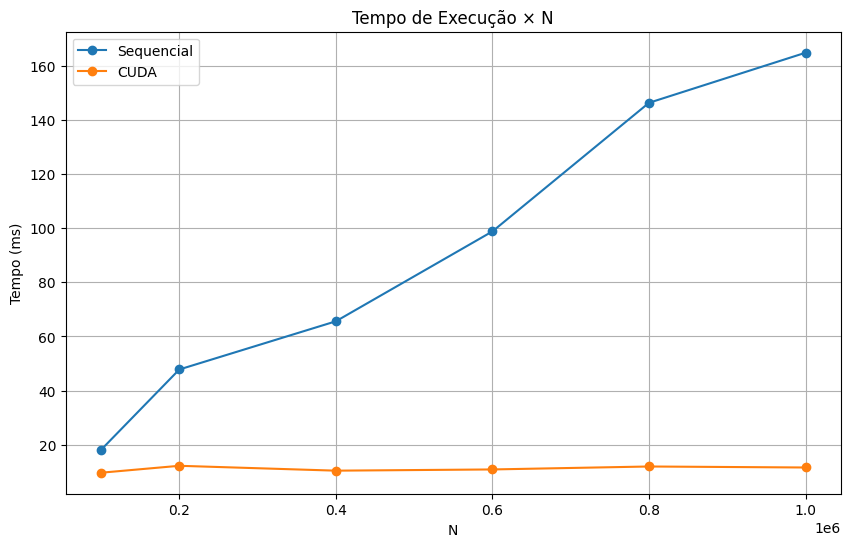

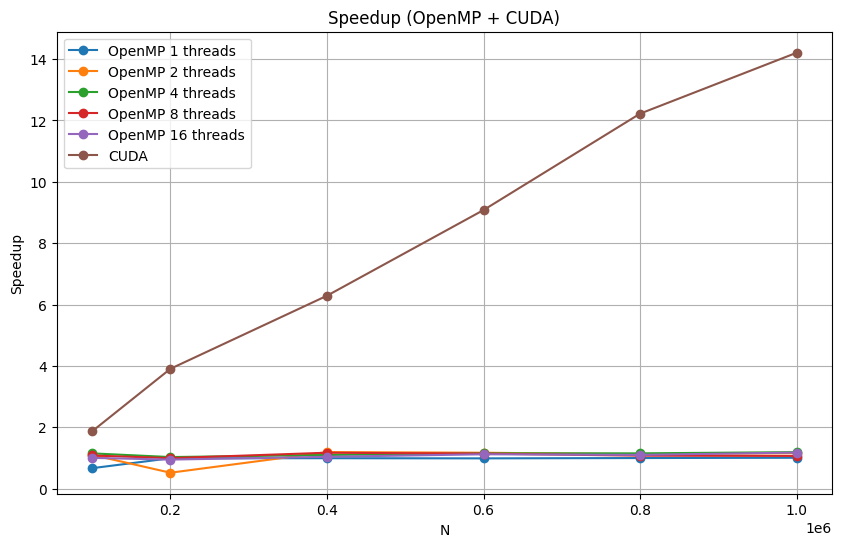

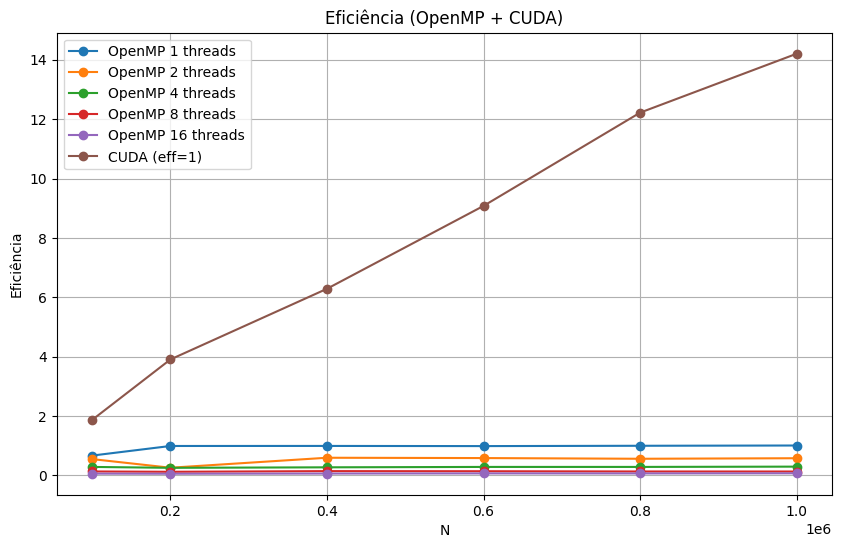

In [11]:
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# ---------------------------------------------------------
# GERAÇÃO DE DADOS COM MISTURA DE FAIXAS
# ---------------------------------------------------------
def gerar_dados(N):
    faixas = [
        np.random.uniform(0, 2,   N//4),
        np.random.uniform(10,12,  N//4),
        np.random.uniform(20,22,  N//4),
        np.random.uniform(30,32,  N - 3*(N//4))
    ]
    return np.concatenate(faixas)


# ---------------------------------------------------------
# EXECUTOR DE COMANDOS
# ---------------------------------------------------------
def run(cmd):
    """
    Executa comando e retorna:
    - tempo total
    - tempo_kernel
    - tempo_h2d
    - tempo_d2h
    - stdout completo
    """
    p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    out = p.communicate()[0]

    tempo_total = None
    tempo_kernel = None
    tempo_h2d = None
    tempo_d2h = None

    for line in out.split("\n"):
        if "Tempo total:" in line: # For CUDA output
            try:
                tempo_total = float(line.split("Tempo total:")[1].split("ms")[0].strip())
            except ValueError:
                pass
        elif "Tempo:" in line: # For Naive/OpenMP output
            try:
                # Example: "Iterações: 3 | SSE final: 0.000000 | Tempo: 0.1 ms"
                time_part = line.split("Tempo:")[1].strip()
                tempo_total = float(time_part.split("ms")[0].strip())
            except ValueError:
                pass

        if "Tempo kernel:" in line:
            try:
                tempo_kernel = float(line.split("Tempo kernel:")[1].split("ms")[0].strip())
            except ValueError:
                pass
        if "Tempo H2D:" in line:
            try:
                tempo_h2d = float(line.split("Tempo H2D:")[1].split("ms")[0].strip())
            except ValueError:
                pass
        if "Tempo D2H:" in line:
            try:
                tempo_d2h = float(line.split("Tempo D2H:")[1].split("ms")[0].strip())
            except ValueError:
                pass

    return tempo_total, tempo_kernel, tempo_h2d, tempo_d2h, out


# ---------------------------------------------------------
# CONFIGURAÇÕES DO BENCHMARK
# ---------------------------------------------------------
np.random.seed(1234)
Ns = [100000, 200000, 400000, 600000, 800000, 1000000]
threads_list = [1, 2, 4, 8, 16]
block_sizes = [128, 256, 512]
max_iter = 50
eps = 0.0001

resultados = []


# ---------------------------------------------------------
# LOOP PRINCIPAL DO BENCHMARK
# ---------------------------------------------------------
for N in Ns:
    print(f"\nGerando dados para N={N}")

    # Gera novos dados por N
    np.random.seed(12345 + N)
    dados = gerar_dados(N)

    np.random.seed(123 + N)
    centroides = np.random.uniform(0, 1000, 16)

    np.savetxt("dados.csv", dados, fmt="%.6f")
    np.savetxt("centroides_iniciais.csv", centroides, fmt="%.6f")

    # ------------------------------------------
    # SEQUENCIAL
    # ------------------------------------------
    tempo_seq, _, _, _, _ = run([
        "./kmeans_1d_naive",
        "dados.csv",
        "centroides_iniciais.csv",
        str(max_iter),
        str(eps),
        "assign.csv",
        "centroids.csv"
    ])

    resultados.append(["Sequencial", N, 1, tempo_seq])
    print(f"  SEQ = {tempo_seq:.2f} ms")

    # ------------------------------------------
    # OPENMP
    # ------------------------------------------
    for t in threads_list:
        print(f"  OMP {t} threads")
        tempo_omp, _, _, _, _ = run([
            "bash", "-c",
            f"OMP_NUM_THREADS={t} ./kmeans_1d_omp dados.csv centroides_iniciais.csv {max_iter} {eps} assign.csv centroids.csv"
        ])
        resultados.append(["OpenMP", N, t, tempo_omp])

    # ------------------------------------------
    # CUDA
    # ------------------------------------------
    for blk in block_sizes:
        tempo_total, tempo_kernel, tempo_h2d, tempo_d2h, _ = run([
            "./kmeans_cuda",
            "dados.csv",
            "centroides_iniciais.csv",
            str(max_iter),
            str(eps),
            "assign_cuda.csv",
            "centroids_cuda.csv",
            str(blk)
        ])

        resultados.append([
            "CUDA", N, blk,
            tempo_total, tempo_kernel, tempo_h2d, tempo_d2h
        ])

        print(f"  CUDA block={blk} → total={tempo_total:.2f} ms, kernel={tempo_kernel:.2f}, h2d={tempo_h2d:.2f}, d2h={tempo_d2h:.2f}")




# ---------------------------------------------------------
# SALVAR RESULTADOS
# ---------------------------------------------------------
df = pd.DataFrame(resultados, columns=[
    "Execucao", "N", "Threads",
    "Tempo_total_ms", "Tempo_kernel_ms", "Tempo_h2d_ms", "Tempo_d2h_ms"
])

df.to_csv("resultados_tempo.csv", index=False)

print("\nArquivo salvo: resultados_tempo.csv")


# ---------------------------------------------------------
# GRÁFICOS
# ---------------------------------------------------------

# ------------------- TEMPO × N ----------------------------
plt.figure(figsize=(10,6))
for exe in ["Sequencial", "CUDA"]:
    if exe == "CUDA":
        df_sub = df[df["Execucao"] == exe].groupby("N")["Tempo_total_ms"].min().reset_index()
    else:
        df_sub = df[df["Execucao"] == exe]
    plt.plot(df_sub["N"], df_sub["Tempo_total_ms"], marker="o", label=exe)

plt.title("Tempo de Execução × N")
plt.xlabel("N")
plt.ylabel("Tempo (ms)")
plt.legend()
plt.grid(True)
plt.savefig("tempo_vs_n.png")
print("tempo_vs_n.png gerado")

# ------------------- SPEEDUP ------------------------------
plt.figure(figsize=(10,6))

df_base = df[df["Execucao"]=="Sequencial"].sort_values("N")

# OpenMP
for t in threads_list:
    df_omp = df[(df["Execucao"]=="OpenMP") & (df["Threads"]==t)].sort_values("N")
    speedup = df_base["Tempo_total_ms"].values / df_omp["Tempo_total_ms"].values
    plt.plot(df_omp["N"], speedup, marker="o", label=f"OpenMP {t} threads")

# CUDA
df_cuda_best = df[df["Execucao"]=="CUDA"].groupby("N")["Tempo_total_ms"].min().reset_index()
df_cuda_best = df_cuda_best.sort_values("N") # Ensure it's sorted by N
speedup_cuda = df_base["Tempo_total_ms"].values / df_cuda_best["Tempo_total_ms"].values
plt.plot(df_cuda_best["N"], speedup_cuda, marker="o", label="CUDA")

plt.title("Speedup (OpenMP + CUDA)")
plt.xlabel("N")
plt.ylabel("Speedup")
plt.legend()
plt.grid(True)
plt.savefig("speedup_total.png")
print("speedup_total.png gerado")

# ------------------- EFICIÊNCIA ---------------------------
plt.figure(figsize=(10,6))

for t in threads_list:
    df_omp = df[(df["Execucao"]=="OpenMP") & (df["Threads"]==t)].sort_values("N")
    efic = (df_base["Tempo_total_ms"].values / df_omp["Tempo_total_ms"].values) / t
    plt.plot(df_omp["N"], efic, marker="o", label=f"OpenMP {t} threads")

# Eficiência CUDA (speedup / 1)
plt.plot(df_cuda_best["N"], speedup_cuda, marker="o", label="CUDA (eff=1)")

plt.title("Eficiência (OpenMP + CUDA)")
plt.xlabel("N")
plt.ylabel("Eficiência")
plt.legend()
plt.grid(True)
plt.savefig("eficiencia_total.png")
print("eficiencia_total.png gerado")

print("\n Todos os gráficos foram gerados:")
print(" - tempo_vs_n.png")
print(" - speedup_total.png")
print(" - eficiencia_total.png")